In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import sqlite3
import cv2
import numpy as np
import pandas as pd

X = np.load("data/processed/silhouettes_64.npz")["X"]
data = pd.read_csv("data/processed/dataset.csv")


def contour_features(sil):
    mask = (sil > 127).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    peri = cv2.arcLength(c, True)
    hull_area = cv2.contourArea(cv2.convexHull(c))
    (_, _), r = cv2.minEnclosingCircle(c)
    (_, _), (rw, rh), _ = cv2.minAreaRect(c)
    hu = cv2.HuMoments(cv2.moments(c)).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-30)

    f = {
        "area": area,
        "perimeter": peri,
        "circularity": 4 * np.pi * area / peri ** 2,
        "solidity": area / hull_area,
        "circle_fill": area / (np.pi * r ** 2),
        "rect_fill": area / (rw * rh),
        "rect_aspect": max(rw, rh) / max(min(rw, rh), 1e-6),
        "n_vertices_2": len(cv2.approxPolyDP(c, 0.02 * peri, True)),
        "n_vertices_4": len(cv2.approxPolyDP(c, 0.04 * peri, True)),
    }
    for i, v in enumerate(hu):
        f[f"hu{i + 1}"] = v
    return f


feats = pd.DataFrame([contour_features(s) for s in X])
feats.insert(0, "id", np.arange(1, len(X) + 1))      # same ids as the database
feats["label"] = data["label"]
feats["source"] = data["source"]
feats["split"] = data["split"]

print(feats.shape)
print(feats.groupby("label")[["circularity", "solidity", "circle_fill",
                              "rect_fill", "n_vertices_2", "n_vertices_4"]].mean().round(3))

(4150, 20)
          circularity  solidity  circle_fill  rect_fill  n_vertices_2  \
label                                                                   
circle          0.894     0.985        0.962      0.789         8.001   
hexagon         0.824     0.974        0.824      0.750         6.031   
pentagon        0.790     0.970        0.765      0.706         5.114   
square          0.753     0.980        0.653      0.971         4.022   
triangle        0.567     0.951        0.437      0.522         3.085   

          n_vertices_4  
label                   
circle           7.777  
hexagon          6.000  
pentagon         5.000  
square           4.000  
triangle         3.003  


In [2]:
conn = sqlite3.connect("data/shapes.db")
feats.to_sql("features", conn, if_exists="replace", index=False)
conn.commit()
feats.to_csv("data/processed/features.csv", index=False)

pd.read_sql("""SELECT i.label, AVG(f.circularity) circ, AVG(f.n_vertices_4) verts
               FROM images i JOIN features f ON i.id = f.id
               GROUP BY i.label""", conn)

,label,circ,verts
0,circle,0.893959,7.776842
1,hexagon,0.823675,6.000000
2,pentagon,0.790116,5.000000
3,square,0.753146,4.000000
4,triangle,0.566512,3.003158


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
FEATS = [c for c in feats.columns if c not in ("id", "label", "source", "split")]
train = (feats["split"] == "train").to_numpy()

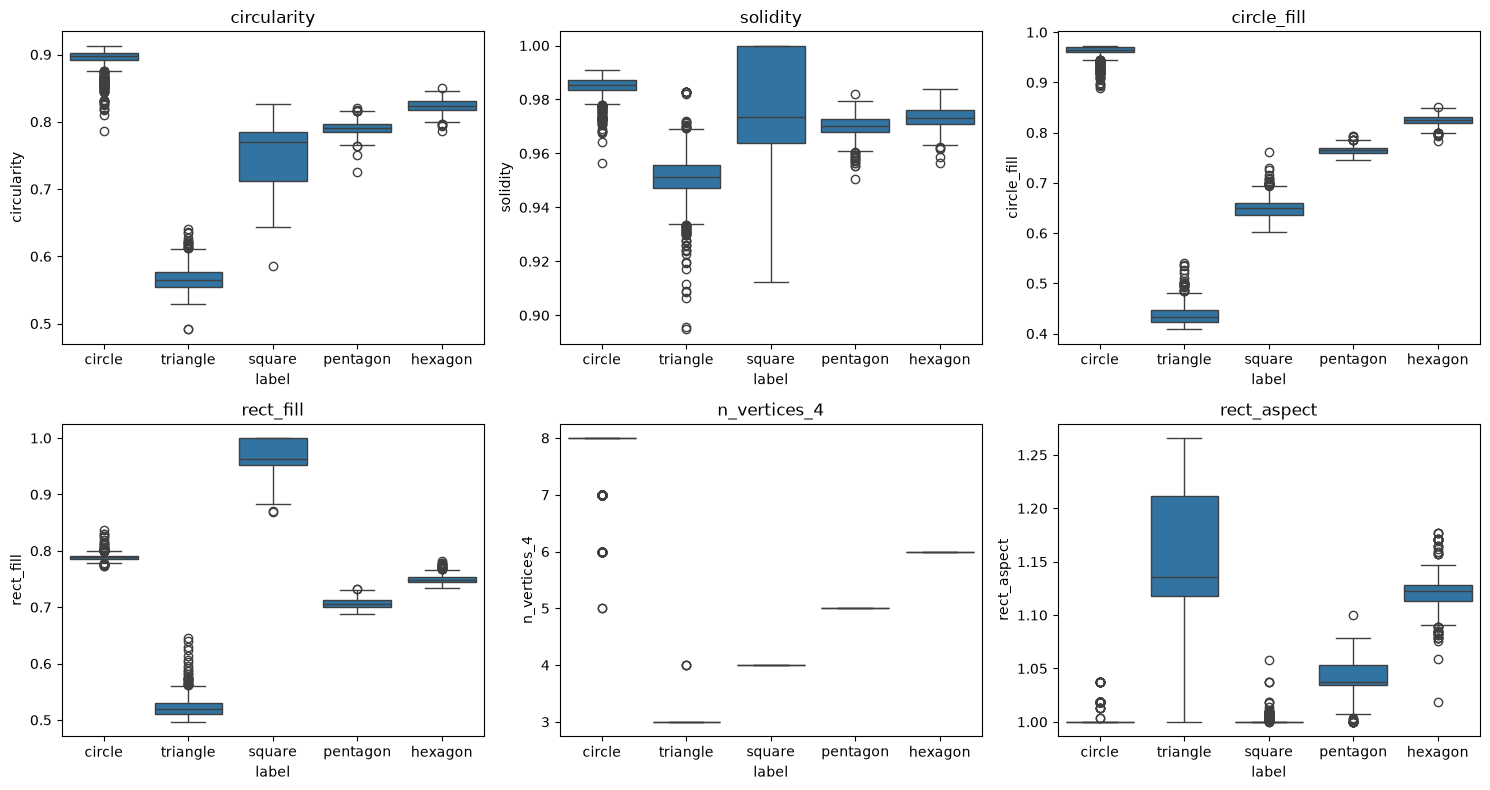

In [4]:
sel = ["circularity", "solidity", "circle_fill", "rect_fill", "n_vertices_4", "rect_aspect"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), sel):
    sns.boxplot(data=feats, x="label", y=col, order=CLASSES, ax=ax)
    ax.set_title(col)
plt.tight_layout()
fig.savefig("outputs/feature_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

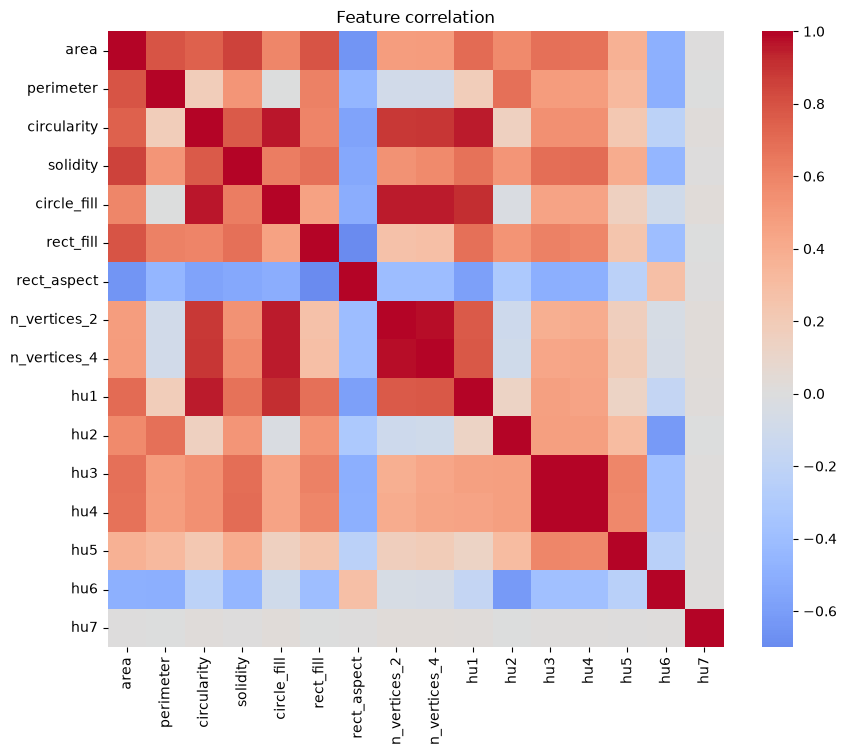

circle_fill   hu1             0.917984
circularity   hu1             0.950008
circle_fill   n_vertices_2    0.953465
              n_vertices_4    0.956739
circularity   circle_fill     0.966272
n_vertices_2  n_vertices_4    0.979660
hu3           hu4             0.994871
dtype: float64


In [5]:
corr = feats[FEATS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Feature correlation")
plt.savefig("outputs/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print(pairs[pairs.abs() > 0.9].sort_values())

components for 95% variance: 8 of 16


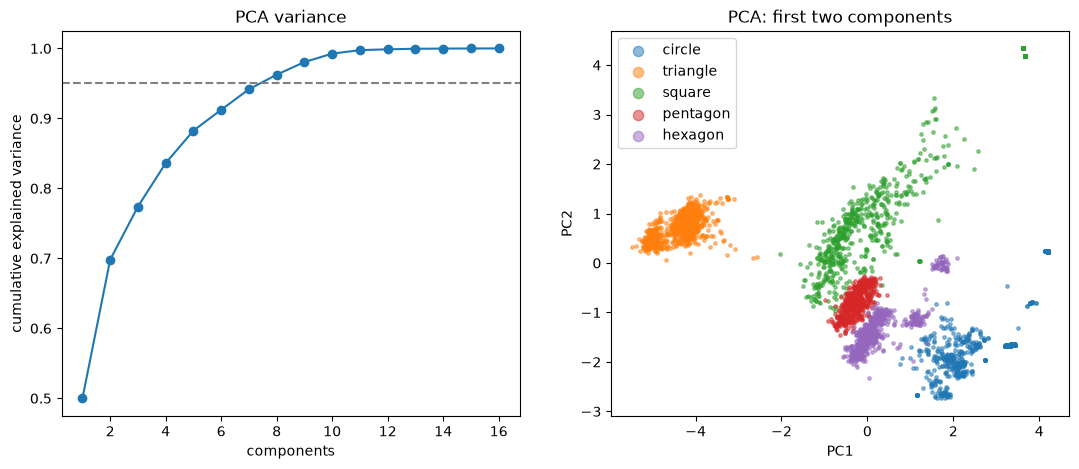

In [6]:
scaler = StandardScaler().fit(feats.loc[train, FEATS])
Z = scaler.transform(feats[FEATS])
pca = PCA().fit(Z[train])

cum = np.cumsum(pca.explained_variance_ratio_)
print("components for 95% variance:", int(np.argmax(cum >= 0.95)) + 1, "of", len(FEATS))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, len(cum) + 1), cum, marker="o")
axes[0].axhline(0.95, color="gray", ls="--")
axes[0].set(xlabel="components", ylabel="cumulative explained variance", title="PCA variance")

P = pca.transform(Z)
for c in CLASSES:
    m = (feats["label"] == c).to_numpy()
    axes[1].scatter(P[m, 0], P[m, 1], s=6, alpha=0.5, label=c)
axes[1].legend(markerscale=3)
axes[1].set(xlabel="PC1", ylabel="PC2", title="PCA: first two components")
fig.savefig("outputs/feature_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced")
rf.fit(feats.loc[train, FEATS], feats.loc[train, "label"])
imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=False)
print(imp.round(3))

hu1             0.195
rect_fill       0.188
circle_fill     0.185
n_vertices_4    0.129
n_vertices_2    0.072
circularity     0.065
rect_aspect     0.061
area            0.046
hu3             0.037
perimeter       0.010
hu4             0.005
solidity        0.004
hu2             0.003
hu5             0.000
hu6             0.000
hu7             0.000
dtype: float64


      id   label     source
219  220  square  generated
222  223  square  generated
368  369  square  generated
800  801  circle  generated
801  802  circle  generated
802  803  circle  generated
803  804  circle  generated
805  806  circle  generated
806  807  circle  generated
808  809  circle  generated
809  810  circle  generated
812  813  circle  generated


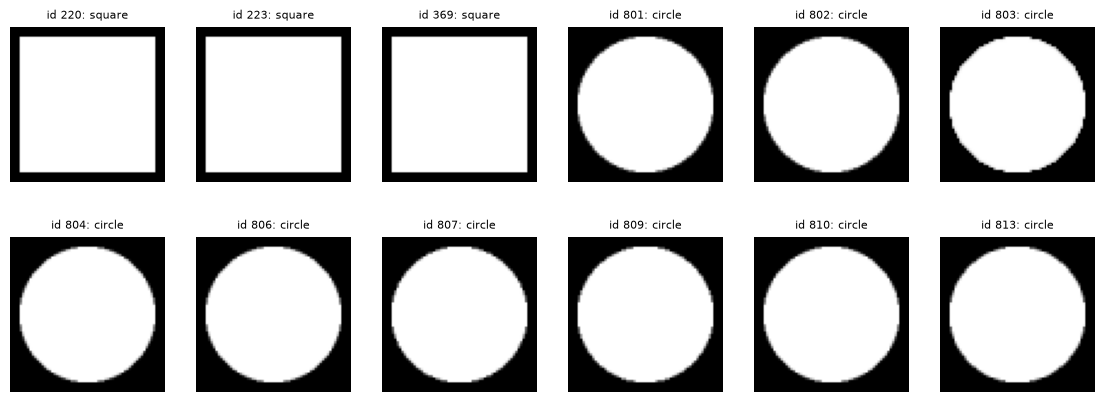

In [8]:
P = pca.transform(Z)
out = feats[(P[:, 1] > 3.8) | (P[:, 0] > 3.3)]
print(out[["id", "label", "source"]].head(12))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.ravel(), out["id"].head(12)):
    ax.imshow(X[i - 1], cmap="gray")
    ax.set_title(f"id {i}: {feats.loc[i - 1, 'label']}", fontsize=8)
    ax.axis("off")
plt.show()